# Visualize Model Predictions

This notebook loads a trained model and visualizes its predictions on a new sample.

In [1]:
import sys
import json
import random
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import napari
from scipy.interpolate import griddata
from pathlib import Path



project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / 'src'))
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

sys.path.append(f"{project_root}src/")
# Import utilities
from utilities import KernelNN, KernelNN_subgraph, setup_device, get_output_affinities
from plot_utilities import plot_results_napari, plot_results_matplotlib

# Device setup
device = setup_device()
print(f'Using device: {device}')

Using device: mps


In [13]:
# choose data
model_type = 'subgraph'


# ---------------------------------------------------------------------------
sys.path.append(f"{project_root}/ERA5/scripts/")
from utilities_era5 import ERA5_Graph_Generator as Data_Generator


# Paths
trained_models_path = project_root / 'ERA5' / 'trained_models' / model_type
training_logs_path = trained_models_path / 'logs'
data_path = project_root.parent / 'ERA5' / 'data'  # Adjust if needed

print('Available models:\n')
files = os.listdir(trained_models_path)

for f in files:
    if Path(f).suffix == ".pth":
        print(f)


Available models:

base-subgraph-2026-01-28_t14-37-39.pth
base-subgraph-2026-02-02_t20-08-50.pth


## 2. Load Model and Configuration

In [ ]:
# Set model ID
model_id = 'base-2026-01-29_t15-48-51.pth'  



# ---------------------------------------------------------------------------
if model_id.endswith('.pth'):
    model_id = model_id[:-4]

# Load full configuration (includes model, dataset, and training configs)
config_path = f'{training_logs_path}/configs/{model_id}.json'
with open(config_path, 'r') as f:
    config = json.load(f)

# Load loss records
loss_df = pd.read_csv(f'{training_logs_path}/loss_records/{model_id}.csv')

print('Configuration:')
for key, value in config.items():
    print(f'  {key}: {value}')

print(f'\Training completed {len(loss_df)} epochs')
print(f'Final training loss: {loss_df["loss"].iloc[-1]:.4f}')
print(f'Final validation loss: {loss_df["val_loss"].iloc[-1]:.4f}')

Configuration:
  mode: regular
  dataset_id: base
  model_id: base
  epochs: 20
  learning_rate: 1e-05
  scheduler_step: 4
  scheduler_gamma: 0.8
  width: 32
  ker_width: 32
  depth: 4
  node_features: 14
  edge_attr: 7
  out_width: 3
  data_folder_path: ../data/
  dataset_save_path: ../datasets/regular/
  lat_min: 30
  lat_max: 70
  lon_min: -10
  lon_max: 30
  N: 5000
  k: 10
  perplexity: 10
  sampling_method: random
  train_date_start_end: ['2018-01-01', '2018-01-31']
  test_date_start_end: ['2018-02-01', '2018-02-10']
  train_samples_per_date: 50
  test_samples_per_date: 20
  feature_mode: channel_and_position
  vars: ['w', 'v', 'z', 'q', 'r', 't', 'd', 'o3', 'pv', 'u', 'vo']
\Training completed 6 epochs
Final training loss: 57369.1856
Final validation loss: 57369.0744


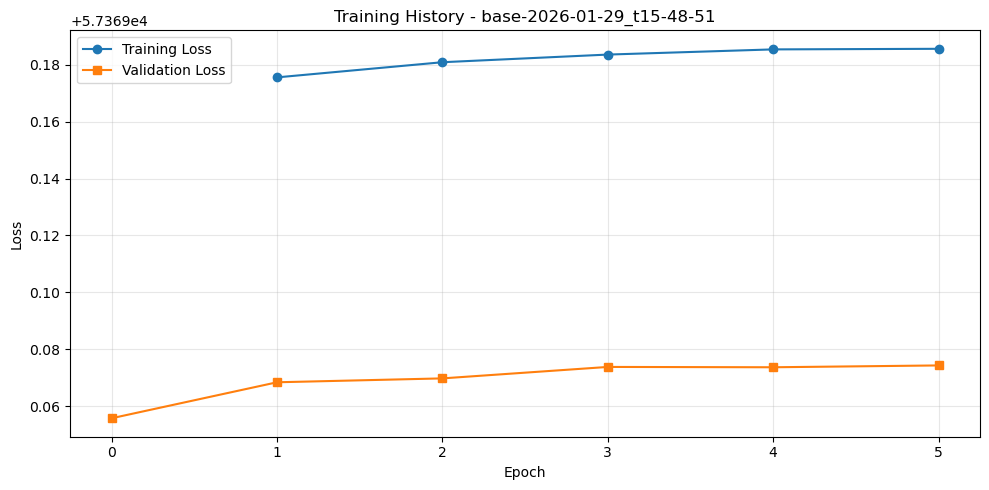

In [12]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_df['epoch'], loss_df['loss'], label='Training Loss', marker='o')
ax.plot(loss_df['epoch'], loss_df['val_loss'], label='Validation Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Training History - {model_id}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
if model_type == "regular":
    lat_min = config["lat_min"]
    lat_max = config["lat_max"]
    lon_min = config["lon_min"]
    lon_max = config["lon_max"]
    N = config["N"]
    k = config["k"]
    perplexity = config["perplexity"]
    sampling_method = config["sampling_method"]
    train_date_start_end = config["train_date_start_end"]
    test_date_start_end = config["test_date_start_end"]
    train_samples_per_date = config["train_samples_per_date"]
    test_samples_per_date = config["test_samples_per_date"]
    feature_mode = config["feature_mode"]
    vars = config["vars"]
elif model_type == "subgraph":
    data_folder_path = config["data_folder_path"]
    dataset_save_path = config["dataset_save_path"]
    lat_min = config["lat_min"]
    lat_max = config["lat_max"]
    lon_min = config["lon_min"]
    lon_max = config["lon_max"]
    N_in = config["N_in"]
    N_out = config["N_out"]
    k_in = config["k_in"]
    k_out = config["k_out"]
    k_cross = config["k_cross"]
    perplexity = config["perplexity"]
    input_sampling_method = config["input_sampling_method"]
    output_sampling_method = config["output_sampling_method"]
    train_date_start_end = config["train_date_start_end"]
    test_date_start_end = config["test_date_start_end"]
    train_samples_per_date = config["train_samples_per_date"]
    test_samples_per_date = config["test_samples_per_date"]
    feature_mode = config["feature_mode"]
    interpolate_graph_features = config["interpolate_graph_features"]
    vars = config["vars"]


In [14]:
if model_type == "subgraph":
    model = KernelNN_subgraph(
        width=config['width'],  # number features per node after lifting
        ker_width=config['ker_width'],  # dimension of single kernel layer
        depth=config['depth'],  # number of graph layers / message passings
        ker_in=config['edge_attr'],  # number of edge features
        known_node_dim=config['input_node_features'],  # only needed when lifting is applied within model
        unknown_node_dim=config['output_node_features'],
        out_width=config['out_width']
    ).to(device)

elif model_type == "regular":
    model = KernelNN(
        width=config['width'],
        ker_width=config['ker_width'],
        depth=config['depth'],
        ker_in=config['edge_attr'],
        in_width=config['node_features'],
        out_width=config['out_width']
    ).to(device)

# Load trained weights
model_path = f'{trained_models_path}/{model_id}.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(f'Model loaded: {model_id}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded: base-subgraph-2026-01-28_t14-37-39
Total parameters: 73,379


## 3. Create New Sample

Use the same functionality as dataset creation to generate a single sample.

In [18]:
data_path

PosixPath('/Volumes/T7-storage/ERA5/data')

In [19]:
date = "2018-04-01"



bbox = lon_min, lat_min, lon_max, lat_max
Generator = Data_Generator(data_path)
Generator.load_data(bbox=bbox, vars=vars, filename=f'{date}.nc')


if model_type == "regular":
    print('generate data')
    graph = Generator.sample_graph(N=N, k=k, perplexity=perplexity, sampling_method=sampling_method, gen_feature_mode=feature_mode)
    sample = graph.to(device)

elif model_type == "subgraph":
    print('generate data')
    out_graph = Generator.sample_graph(N=N_out, k=k_out, perplexity=perplexity, sampling_method=output_sampling_method, gen_feature_mode=feature_mode)
    in_graph = Generator.sample_graph(N=N_in, k=k_in, perplexity=perplexity, sampling_method=input_sampling_method, gen_feature_mode=feature_mode)
    cross_graph = Generator.connect_graphs(in_graph=in_graph, out_graph=out_graph, k_cross=k_cross)
    cross_graph["x"] = Generator.construct_output_node_features(cross_graph=cross_graph, interpolate=interpolate_graph_features, gen_feature_mode=feature_mode)
    sample = cross_graph.to(device)


print('predict results')
output = model(sample).detach().cpu().numpy()

generate data
predict results


---
Plot

In [28]:

def plot_results_napari(output_np, gps_np):
    # -----------------------------
    # Input data
    # A: (N, 3)  -> non-normalized RGB channels
    # B: (N, 2)  -> (latitude, longitude)
    # -----------------------------

    # -----------------------------
    # Per-channel normalization
    # -----------------------------
    A=output_np
    A_norm = np.zeros_like(A)
    lat = gps_np[:, 0]
    lon = gps_np[:, 1]

    for c in range(3):
        channel = A[:, c]
        cmin = channel.min()
        cmax = channel.max()
        if cmax > cmin:
            A_norm[:, c] = (channel - cmin) / (cmax - cmin)
        else:
            A_norm[:, c] = 0.0

    # Optional global brightness scaling (prevents additive washout)
    V = 0.5
    A_norm = np.clip(A_norm * V, 0, 1)

    # -----------------------------
    # Create regular lat–lon grid
    # -----------------------------

    grid_size = 300  # adjust resolution here

    lat_grid = np.linspace(lat.min(), lat.max(), grid_size)
    lon_grid = np.linspace(lon.min(), lon.max(), grid_size)

    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    points = np.column_stack([lon, lat])

    # -----------------------------
    # Interpolate each channel
    # -----------------------------

    Red = griddata(points, A_norm[:, 0], (lon_mesh, lat_mesh), method='linear')
    Green = griddata(points, A_norm[:, 1], (lon_mesh, lat_mesh), method='linear')
    Blue = griddata(points, A_norm[:, 2], (lon_mesh, lat_mesh), method='linear')

    Red[np.isnan(Red)] = 0.0
    Green[np.isnan(Green)] = 0.0
    Blue[np.isnan(Blue)] = 0.0

    # -----------------------------
    # Stack into 3 separate layers
    # -----------------------------

    image_stack = np.stack([Red, Green, Blue], axis=0)  # shape: (3, H, W)
    colormap_names = ['red', 'green', 'blue']
    opacity_per_layer = 0.75  # reasonable for additive blending

    # -----------------------------
    # Napari visualization
    # -----------------------------

    viewer = napari.Viewer(show=False)

    for i in range(3):
        viewer.add_image(
            image_stack[i],
            name=f'channel_{colormap_names[i]}',
            colormap=colormap_names[i],
            blending='additive',
            opacity=opacity_per_layer
        ).interpolation = 'linear'

    return viewer

In [34]:
viewer = plot_results_napari(output, cross_graph.target.meta.gps)

In [35]:
viewer.show()

In [24]:
def data_has_nan(data):
    for key, value in data:
        if torch.is_tensor(value):
            if torch.isnan(value).any():
                print(f"NaNs found in '{key}'")
                return True
    return False

data_has_nan(sample)

False

In [25]:
output

array([[-2.2714693e-34,  1.9703464e-34,  2.0947401e-34],
       [-2.2714693e-34,  1.9703464e-34,  2.0947401e-34],
       [-2.2714693e-34,  1.9703464e-34,  2.0947401e-34],
       ...,
       [-2.2714693e-34,  1.9703464e-34,  2.0947401e-34],
       [-2.2714693e-34,  1.9703464e-34,  2.0947401e-34],
       [-2.2714693e-34,  1.9703464e-34,  2.0947401e-34]], dtype=float32)

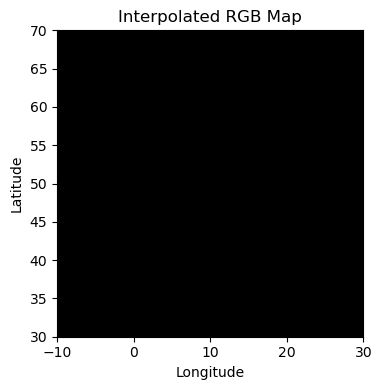

In [20]:
plot_results_matplotlib(output_np=output, gps_np=sample.target.meta.gps)

[0, 1, 2]
(10, 20000)


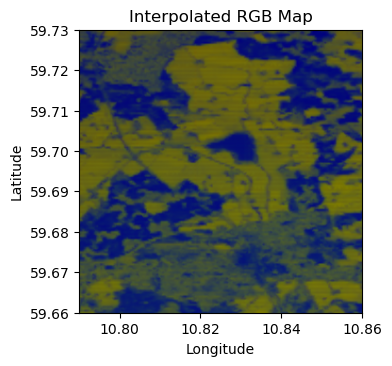

(500, 20000)


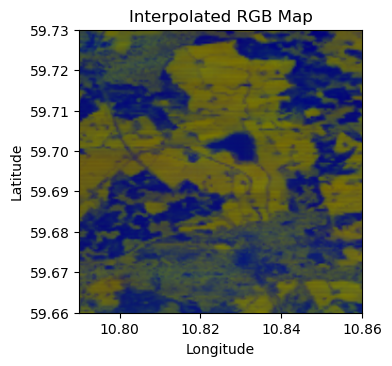

(5000, 20000)


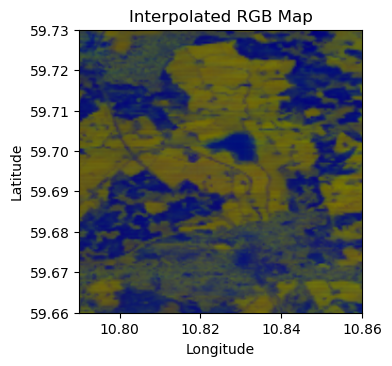

In [53]:
N_in= all
N_out=20000

if N_out ==all:
    idices = [i for i, (x, _) in enumerate(plot_index) if x == N_in]
if N_in ==all:
    idices = [i for i, (_, y) in enumerate(plot_index) if y == N_out]
print(idices)

for i in idices:
    print(plot_index[i])
    display(plots[i])

In [45]:
cross_graph.source.keys()


['sigmas',
 'normed_coords',
 'meta',
 'edge_attr',
 'normed_values',
 'input_affinities',
 'edge_index',
 'x',
 'edge_dist']

In [48]:
in_gps = cross_graph.source.meta.gps

In [ ]:
in_gps[in_gps[:,0]>59.695 and in_gps[:,0]<59.708, and in_gps[:,1]>10.82¢]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [34]:
# Choose a year and file (use test year for out-of-sample prediction)
test_year = 2019  # First test year
tif_path = data_path / f'sat_emb_{test_year}.tif'

if not tif_path.exists():
    print(f'Warning: File not found: {tif_path}')
    print('Available files:')
    for f in sorted(data_path.glob('sat_emb_*.tif')):
        print(f'  {f.name}')
else:
    print(f'Using data file: {tif_path.name}')
    
    # Define bounding box (use config bounds)
    bbox = (
        config['lon_min'],
        config['lat_min'],
        config['lon_max'],
        config['lat_max']
    )
    
    print(f'Bounding box: lat [{bbox[1]}, {bbox[3]}], lon [{bbox[0]}, {bbox[2]}]')
    
    # Load and prepare data
    print('Loading region data...')
    df = prepare_dataframe(str(tif_path), bbox)
    print(f'Loaded {len(df)} grid points')
    
    # Create graph sample using same parameters as training
    print('Creating graph sample...')
    sample = create_sample(
        df=df,
        year=test_year,
        n_points_min= 100000, #config['n_points_min'],
        n_points_max= 100000, #config['n_points_max'],
        k=config['k'],
        perplexity=config['perplexity'],
        lifting_bool=config['lifting_bool'],
        device=device
    )
    
    print(f'Sample created:')
    print(f'  Nodes: {sample.x.shape[0]}')
    print(f'  Edges: {sample.edge_index.shape[1]}')
    print(f'  Node features: {sample.x.shape[1]}')
    print(f'  Edge features: {sample.edge_attr.shape[1]}')
    print(f'  Year: {sample.year}')

Using data file: sat_emb_2019.tif
Bounding box: lat [59.66, 59.73], lon [10.79, 10.86]
Loading region data...
Loaded 606841 grid points
Creating graph sample...
Sample created:
  Nodes: 100000
  Edges: 800000
  Node features: 64
  Edge features: 73
  Year: 2019


## 4. Make Prediction

Run the sample through the trained model.

In [35]:
# Move sample to device
sample = sample.to(device)

# Make prediction
with torch.no_grad():
    output = model(sample)
    predicted_affinities = get_output_affinities(output, sample.edge_index)

print(f'Prediction shape: {output.shape}')
print(f'Output affinities shape: {predicted_affinities.shape}')
print(f'Input affinities shape: {sample.input_affinities.shape}')

Prediction shape: torch.Size([100000, 3])
Output affinities shape: torch.Size([100000, 8])
Input affinities shape: torch.Size([100000, 8])


## 5. Visualize Results

Compare input and predicted affinities.

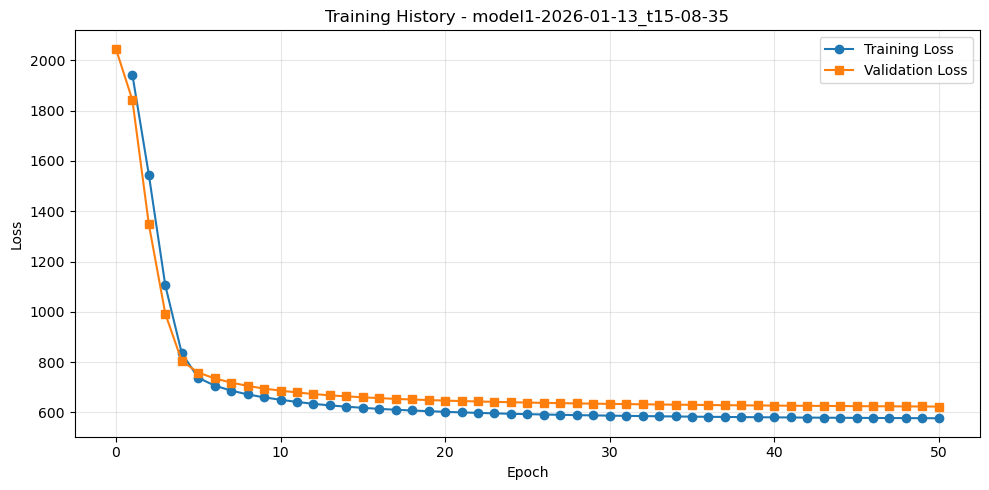

In [33]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_df['epoch'], loss_df['loss'], label='Training Loss', marker='o')
ax.plot(loss_df['epoch'], loss_df['val_loss'], label='Validation Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Training History - {model_id}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

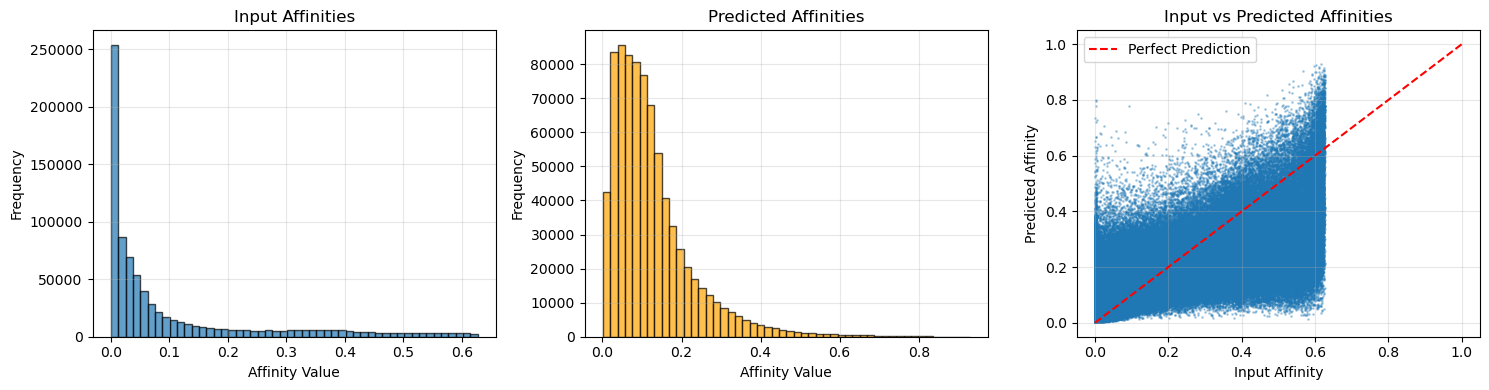

Correlation between input and predicted affinities: 0.7488


In [36]:
# Compare input vs predicted affinities
input_aff = sample.input_affinities.cpu().numpy().flatten()
pred_aff = predicted_affinities.cpu().numpy().flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Input affinities histogram
axes[0].hist(input_aff, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Input Affinities')
axes[0].set_xlabel('Affinity Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Predicted affinities histogram
axes[1].hist(pred_aff, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('Predicted Affinities')
axes[1].set_xlabel('Affinity Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Scatter plot: input vs predicted
axes[2].scatter(input_aff, pred_aff, alpha=0.3, s=1)
axes[2].plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
axes[2].set_title('Input vs Predicted Affinities')
axes[2].set_xlabel('Input Affinity')
axes[2].set_ylabel('Predicted Affinity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute correlation
correlation = np.corrcoef(input_aff, pred_aff)[0, 1]
print(f'Correlation between input and predicted affinities: {correlation:.4f}')

KeyboardInterrupt: 

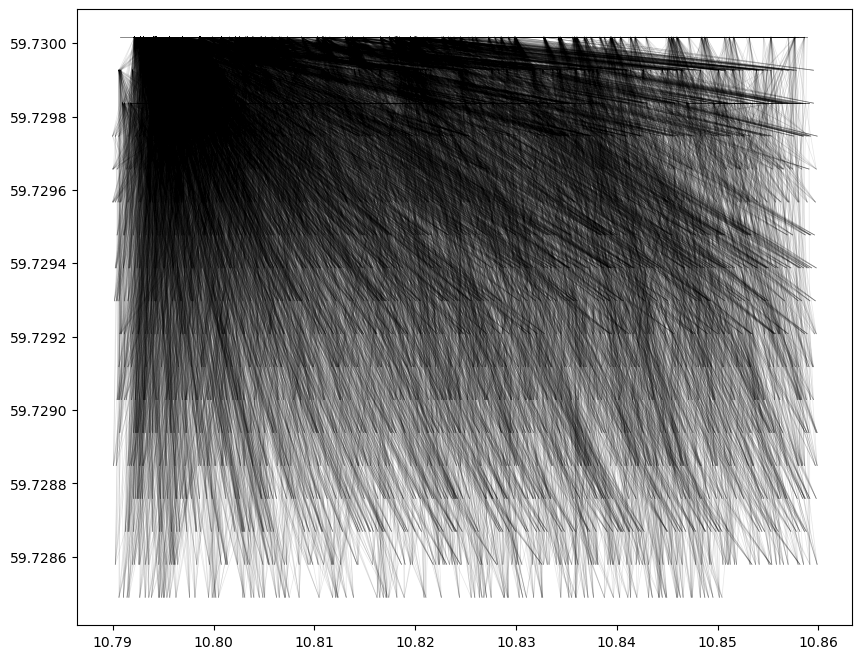

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Node locations
locations = sample.locations

fig, ax = plt.subplots(figsize=(10, 8))

# --- Plot edges FIRST (so they stay behind nodes) ---
edge_index = sample.edge_index.cpu().numpy()
num_edges = edge_index.shape[1]

for i in range(num_edges):
    src, dst = edge_index[:, i]
    ax.plot(
        [locations['lon'].iloc[src], locations['lon'].iloc[dst]],
        [locations['lat'].iloc[src], locations['lat'].iloc[dst]],
        color='black',
        alpha=0.1,      # low alpha to avoid clutter
        linewidth=0.5,
        zorder=1
    )

# --- Plot nodes ---
ax.scatter(
    locations['lon'],
    locations['lat'],
    color='tab:blue',
    s=50,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5,
    zorder=2
)

# --- Labels & styling ---
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    f'Graph Structure: {sample.x.shape[0]} nodes, {num_edges} edges'
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Napari RGB Visualization of Model Predictions

Visualize the 3 output dimensions of the model's predictions as RGB channels.

In [38]:
A = np.array(output.cpu().numpy())
B = np.array(sample.locations)

In [ ]:
# Per point plot

# --- Normalize colors ---
A = A.astype(float)

norms = np.linalg.norm(A, axis=1, keepdims=True)
norms[norms == 0] = 1.0
A_norm = A / norms

# Optional brightness scaling
V = 0.6
colors = np.clip(A_norm * V, 0, 1)

# --- Coordinates ---
points = np.column_stack([B[:, 0], B[:, 1]])  # (lat, lon)

# --- Napari viewer ---
viewer = napari.Viewer()

viewer.add_points(
    points,
    face_color=colors,
    size=5,
    blending='additive',
    name='nodes'
)

napari.run()

In [13]:
# Plot as interpolated images

import numpy as np
import napari
from scipy.interpolate import griddata

# -----------------------------
# Input data
# A: (N, 3)  -> non-normalized RGB channels
# B: (N, 2)  -> (latitude, longitude)
# -----------------------------

A = A.astype(float)
lat = B[:, 0]
lon = B[:, 1]

# -----------------------------
# Per-channel normalization
# -----------------------------

A_norm = np.zeros_like(A)

for c in range(3):
    channel = A[:, c]
    cmin = channel.min()
    cmax = channel.max()
    if cmax > cmin:
        A_norm[:, c] = (channel - cmin) / (cmax - cmin)
    else:
        A_norm[:, c] = 0.0

# Optional global brightness scaling (prevents additive washout)
V = 0.5
A_norm = np.clip(A_norm * V, 0, 1)

# -----------------------------
# Create regular lat–lon grid
# -----------------------------

grid_size = 300  # adjust resolution here

lat_grid = np.linspace(lat.min(), lat.max(), grid_size)
lon_grid = np.linspace(lon.min(), lon.max(), grid_size)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([lon, lat])

# -----------------------------
# Interpolate each channel
# -----------------------------

R = griddata(points, A_norm[:, 0], (lon_mesh, lat_mesh), method='linear')
G = griddata(points, A_norm[:, 1], (lon_mesh, lat_mesh), method='linear')
B = griddata(points, A_norm[:, 2], (lon_mesh, lat_mesh), method='linear')

R[np.isnan(R)] = 0.0
G[np.isnan(G)] = 0.0
B[np.isnan(B)] = 0.0

# -----------------------------
# Stack into RGB image
# -----------------------------

rgb_image = np.stack([R, G, B], axis=-1)  # (H, W, 3)

# -----------------------------
# Napari visualization
# -----------------------------

viewer = napari.Viewer()

viewer.add_image(
    rgb_image,
    name="Interpolated RGB",
    rgb=True,
    interpolation="linear"
)

napari.run()


/var/folders/sw/tjsbk4pj7q9gs_91lbj2_2rc0000gp/T/ipykernel_79901/424639933.py:73: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  viewer.add_image(


In [39]:
import numpy as np
import napari
from scipy.interpolate import griddata

# -----------------------------
# Input data
# A: (N, 3)  -> non-normalized RGB channels
# B: (N, 2)  -> (latitude, longitude)
# -----------------------------

A = A.astype(float)
lat = B[:, 0]
lon = B[:, 1]

# -----------------------------
# Per-channel normalization
# -----------------------------

A_norm = np.zeros_like(A)

for c in range(3):
    channel = A[:, c]
    cmin = channel.min()
    cmax = channel.max()
    if cmax > cmin:
        A_norm[:, c] = (channel - cmin) / (cmax - cmin)
    else:
        A_norm[:, c] = 0.0

# Optional global brightness scaling (prevents additive washout)
V = 0.5
A_norm = np.clip(A_norm * V, 0, 1)

# -----------------------------
# Create regular lat–lon grid
# -----------------------------

grid_size = 300  # adjust resolution here

lat_grid = np.linspace(lat.min(), lat.max(), grid_size)
lon_grid = np.linspace(lon.min(), lon.max(), grid_size)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([lon, lat])

# -----------------------------
# Interpolate each channel
# -----------------------------

Red = griddata(points, A_norm[:, 0], (lon_mesh, lat_mesh), method='linear')
Green = griddata(points, A_norm[:, 1], (lon_mesh, lat_mesh), method='linear')
Blue = griddata(points, A_norm[:, 2], (lon_mesh, lat_mesh), method='linear')

Red[np.isnan(Red)] = 0.0
Green[np.isnan(Green)] = 0.0
Blue[np.isnan(Blue)] = 0.0

# -----------------------------
# Stack into 3 separate layers
# -----------------------------

image_stack = np.stack([Red, Green, Blue], axis=0)  # shape: (3, H, W)
colormap_names = ['red', 'green', 'blue']
opacity_per_layer = 0.75  # reasonable for additive blending

# -----------------------------
# Napari visualization
# -----------------------------

viewer = napari.Viewer()

for i in range(3):
    viewer.add_image(
        image_stack[i],
        name=f'channel_{colormap_names[i]}',
        colormap=colormap_names[i],
        blending='additive',
        opacity=opacity_per_layer,
        interpolation='cubic'
    )

napari.run()


/var/folders/sw/tjsbk4pj7q9gs_91lbj2_2rc0000gp/T/ipykernel_79901/376407551.py:74: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  viewer.add_image(
/var/folders/sw/tjsbk4pj7q9gs_91lbj2_2rc0000gp/T/ipykernel_79901/376407551.py:74: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  viewer.add_image(
/var/folders/sw/tjsbk4pj7q9gs_91lbj2_2rc0000gp/T/ipykernel_79901/376407551.py:74: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  viewer.add_image(
